# Banking Dataset: Synthetic Data Quality Assessment with Mahalanobis Distance

This notebook:
1. Loads the **Banking** dataset (bank-full.csv) and prepares it for synthesis.
2. Generates synthetic data using **SDV** models: **CTGAN**, **CopulaGAN**, **Gaussian Copula**, and **TVAE**.
3. Assesses synthetic data quality using **Mahalanobis distance** (distribution-based, nearest-neighbor, greedy mapping, and Hungarian matching).

**Mahalanobis distance** measures how far a point is from a distribution in terms of standard deviations, accounting for correlations. Lower distances indicate better fidelity to the real data distribution.

## 1. Data loading and preparation

In [1]:
import warnings
import numpy as np
import pandas as pd
import os
warnings.filterwarnings('ignore')

cwd = os.getcwd()
candidates = [cwd, os.path.join(cwd, '..'), os.path.join(cwd, '..', '..')]
ROOT = cwd
for c in candidates:
    p = os.path.abspath(c)
    if os.path.isdir(os.path.join(p, 'Datasets')):
        ROOT = p
        break
DATA_PATH = os.path.join(ROOT, "Datasets", "bank-full.csv")

bank_data = pd.read_csv(DATA_PATH, sep=';')
bank_data = bank_data.head(5000).reset_index(drop=True)

from sklearn.preprocessing import OrdinalEncoder
cat_cols = bank_data.select_dtypes(include='object').columns.tolist()
if cat_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    bank_data[cat_cols] = encoder.fit_transform(bank_data[cat_cols])

feature_cols = [c for c in bank_data.columns]
data = bank_data[feature_cols].astype(float)
data_numeric = data.copy()

print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.info()

Data shape: (5000, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        5000 non-null   float64
 1   job        5000 non-null   float64
 2   marital    5000 non-null   float64
 3   education  5000 non-null   float64
 4   default    5000 non-null   float64
 5   balance    5000 non-null   float64
 6   housing    5000 non-null   float64
 7   loan       5000 non-null   float64
 8   contact    5000 non-null   float64
 9   day        5000 non-null   float64
 10  month      5000 non-null   float64
 11  duration   5000 non-null   float64
 12  campaign   5000 non-null   float64
 13  pdays      5000 non-null   float64
 14  previous   5000 non-null   float64
 15  poutcom

In [2]:
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(bank_data)
print(f"Numeric feature matrix shape: {data_numeric.shape}")

Numeric feature matrix shape: (5000, 17)


## 2. SDV models: fit and sample

In [3]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

models = {
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(bank_data)

print("All models fitted!")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...
All models fitted!


In [4]:
n_rows = len(bank_data)
synthetic_data = {}

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)
    synth_numeric = synthetic_data[name][feature_cols].astype(float)
    synthetic_data[name + "_numeric"] = synth_numeric

# Drop outcome column(s) before Mahalanobis (use features only)
outcome_cols = ['y']
data_for_mahalanobis = data_numeric.drop(columns=outcome_cols)
feature_cols_maha = data_for_mahalanobis.columns.tolist()
for name in models:
    synthetic_data[name + "_numeric"] = synthetic_data[name + "_numeric"].drop(columns=outcome_cols)

print(f"Real data size: {n_rows}. Sampled {n_rows} synthetic rows per model.")
display(synthetic_data["GaussianCopula"].head())

Real data size: 5000. Sampled 5000 synthetic rows per model.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,44,11.0,1.0,3.0,0.0,946,1.0,0.0,0.0,16,0.0,408,9,-1,0,0.0,0.0
1,43,4.0,1.0,3.0,0.0,1878,0.0,0.0,0.0,8,0.0,236,3,-1,0,0.0,0.0
2,47,6.0,1.0,0.0,0.0,762,1.0,0.0,0.0,16,0.0,167,28,-1,0,0.0,0.0
3,38,11.0,1.0,1.0,0.0,727,1.0,0.0,0.0,12,0.0,138,2,-1,0,0.0,0.0
4,25,1.0,1.0,1.0,0.0,1354,1.0,0.0,0.0,12,0.0,25,2,-1,0,0.0,0.0


## 3. Mahalanobis distance: setup

We estimate **mean** and **inverse covariance** of the real data, then compute Mahalanobis distance for each synthetic sample to this distribution.

In [5]:
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = inv(cov + (reg * 10) * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum('ij,jk,ik->i', delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0))

real_matrix = data_for_mahalanobis.to_numpy()
mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (16,), Inv_cov shape: (16, 16)


## 4. Quality assessment: Mahalanobis distance to distribution (per model)

In [6]:
mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)
    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "dists": dists,
    }

dist_df = pd.DataFrame(
    {name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
},
    index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"],
).T
dist_df.index.name = "Model"
print("Mahalanobis distance to real distribution (lower is better):")
display(dist_df)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,5.215735,4.069532,3.246168,0.998373,21.423453
CTGAN,3.211173,2.941873,1.379542,0.881975,11.401025
CopulaGAN,3.328042,3.022108,1.398455,0.726737,10.505835
TVAE,2.250495,2.245195,0.418642,1.239134,7.317849


## 5. Nearest-neighbor Mahalanobis distance (per synthetic sample)

For each synthetic sample we compute the **Mahalanobis distance to its nearest real sample**. Mean/min/max of these distances indicate how close synthetic points lie to the real cloud.

In [7]:
from scipy.spatial.distance import cdist

def nearest_neighbor_mahalanobis(synth_matrix, real_matrix, inv_cov):
    """For each synthetic row, distance to nearest real (Mahalanobis). Returns 1D array."""
    D = cdist(synth_matrix, real_matrix, metric="mahalanobis", VI=inv_cov)
    return np.min(D, axis=1)

nn_results = {}
for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    nn_dists = nearest_neighbor_mahalanobis(synth_numeric, real_matrix, inv_cov_real)
    nn_results[name] = {
        "mean_nn": float(np.mean(nn_dists)),
        "median_nn": float(np.median(nn_dists)),
        "std_nn": float(np.std(nn_dists)),
        "min_nn": float(np.min(nn_dists)),
        "max_nn": float(np.max(nn_dists)),
    }

nn_summary = pd.DataFrame(nn_results).T
nn_summary.index.name = "Model"
print("Nearest-neighbor Mahalanobis distance (synthetic → closest real), lower is better:")
display(nn_summary)

Nearest-neighbor Mahalanobis distance (synthetic → closest real), lower is better:


,mean_nn,median_nn,std_nn,min_nn,max_nn
Model,,,,,
GaussianCopula,1.794030,1.567831,1.008523,0.086906,8.259983
CTGAN,0.942178,0.797867,0.588141,0.025830,6.189779
CopulaGAN,1.029960,0.889642,0.599867,0.027670,4.694927
TVAE,0.343252,0.331525,0.141949,0.004123,1.699456


## 6. Greedy matching (one-to-one)

Iteratively pair the **real** and **synthetic** samples with the smallest Mahalanobis distance, then remove both and repeat. Total distance and mean distance are reported and compared to Hungarian.

In [33]:
def greedy_match_mahalanobis(real_matrix, synth_matrix, inv_cov):
    """Fast O(n^2 log n): sort all pairs by distance, then assign in order."""
    D = cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)
    n = D.shape[0]
    # Flatten to (distance, i, j) and sort by distance
    ij = np.arange(n)
    ii, jj = np.meshgrid(ij, ij, indexing='ij')
    pairs = np.column_stack([D.ravel(), ii.ravel(), jj.ravel()])
    pairs = pairs[pairs[:, 0].argsort(kind='mergesort')]
    used_real = set()
    used_synth = set()
    row_ind, col_ind = [], []
    matched_distances = []
    for k in range(len(pairs)):
        d, i, j = pairs[k, 0], int(pairs[k, 1]), int(pairs[k, 2])
        if len(row_ind) >= n:
            break
        if i not in used_real and j not in used_synth:
            row_ind.append(i)
            col_ind.append(j)
            matched_distances.append(float(d))
            used_real.add(i)
            used_synth.add(j)
    return np.array(row_ind), np.array(col_ind), np.array(matched_distances)

greedy_results = {}
n_samples = len(real_matrix)
for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    rind, cind, distances = greedy_match_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    greedy_results[name] = {
        "total_distance": float(distances.sum()),
        "mean_distance_per_match": float(distances.mean()),
        "median_distance_per_match": float(np.median(distances)),
        "std_distance_per_match": float(np.std(distances)),
    }

greedy_summary = pd.DataFrame(greedy_results).T
greedy_summary.index.name = "Model"
print("Greedy matching (Mahalanobis distance), lower is better:")
display(greedy_summary)

Greedy matching (Mahalanobis distance), lower is better:


,total_distance,mean_distance_per_match,median_distance_per_match,std_distance_per_match
Model,,,,
GaussianCopula,20758.627507,4.151726,2.494945,4.045435
CTGAN,8085.015474,1.617003,1.047769,1.788862
CopulaGAN,8163.085843,1.632617,1.121954,1.775078
TVAE,10570.881179,2.114176,1.705293,1.947207


## 7. Hungarian algorithm: optimal one-to-one matching

In [34]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}
for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name + "_numeric"].to_numpy()
    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]
    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {name: [r["mean_distance_per_match"], r["median_distance_per_match"], r["std_distance_per_match"], r["max_distance_per_match"]]
    for name, r in hungarian_results.items()
},
    index=["mean_distance_per_match", "median_distance_per_match", "std_distance_per_match", "max_distance_per_match"],
).T
hungarian_summary.index.name = "Model"
print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,3.946944,2.631307,3.522563,31.274646
CTGAN,1.475811,1.112981,1.490454,25.661260
CopulaGAN,1.495696,1.138543,1.534211,22.368770
TVAE,2.052543,1.697042,1.832571,23.444362


## 8. Compare Greedy vs Hungarian (mean distance per match)

In [10]:
compare = pd.DataFrame({
    "Greedy_mean_distance": [greedy_results[m]["mean_distance_per_match"] for m in hungarian_results],
    "Hungarian_mean_distance": [hungarian_results[m]["mean_distance_per_match"] for m in hungarian_results],
}, index=list(hungarian_results.keys()))
compare.index.name = "Model"
display(compare)

,Greedy_mean_cost,Hungarian_mean_cost
Model,,
GaussianCopula,4.151726,3.946944
CTGAN,1.617003,1.475811
CopulaGAN,1.632617,1.495696
TVAE,2.114176,2.052543


## 9. Visualization: mean Mahalanobis distance by model

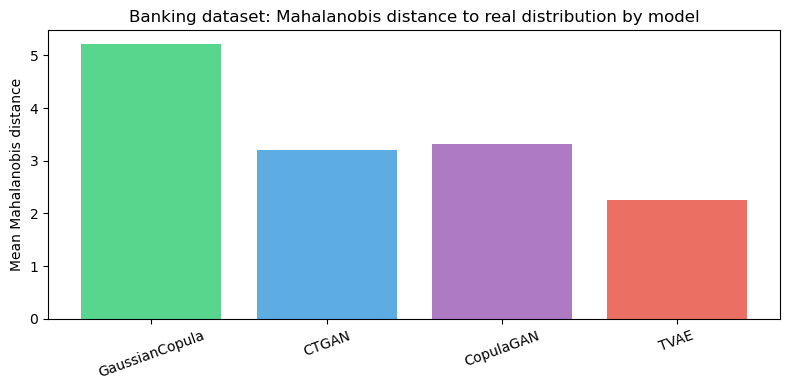

In [11]:
import matplotlib.pyplot as plt

models_order = ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]
means = [mahalanobis_results[m]["mean"] for m in models_order]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(models_order, means, color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'], alpha=0.8)
ax.set_ylabel("Mean Mahalanobis distance")
ax.set_title("Banking dataset: Mahalanobis distance to real distribution by model")
plt.xticks(rotation=20)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "Mahalanobis_distance", "Banking", "figures"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "Mahalanobis_distance", "Banking", "figures", "mahalanobis_mean_by_model.png"), dpi=150, bbox_inches='tight')
plt.show()

## 10. Export Hungarian-matched pairs (e.g. GaussianCopula) to Excel

In [12]:
def export_hungarian_mahalanobis_excel(real_df, synth_df, row_ind, col_ind, matched_distances, num_cols, filename):
    real_out = real_df[num_cols].copy()
    real_out.insert(0, "Real_Index", range(len(real_out)))
    synth_out = synth_df[num_cols].copy()
    synth_out.insert(0, "Synthetic_Index", range(len(synth_out)))
    records = []
    for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
        rec = {"Real_Index": int(r_i), "Synthetic_Index": int(s_i), "Mahalanobis_Distance": float(dist)}
        for c in num_cols:
            rec[f"Real_{c}"] = real_df.iloc[r_i][c]
            rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
        records.append(rec)
    matched_df = pd.DataFrame(records)
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        real_out.to_excel(writer, sheet_name="Real_Samples", index=False)
        synth_out.to_excel(writer, sheet_name="Synthetic_Samples", index=False)
        matched_df.to_excel(writer, sheet_name="Matched_Pairs", index=False)
    print(f"Excel file created: {filename}")

name = "GaussianCopula"
r = hungarian_results[name]
real_df = pd.DataFrame(real_matrix, columns=feature_cols_maha)
synth_df = synthetic_data[name + "_numeric"]
D = pairwise_mahalanobis(real_matrix, synthetic_data[name + "_numeric"].to_numpy(), inv_cov_real)
matched_dists = D[r["row_ind"], r["col_ind"]]
out_path = os.path.join(ROOT, "Mahalanobis_distance", "Banking", "GaussianCopula_Mahalanobis_Hungarian_Matching.xlsx")
export_hungarian_mahalanobis_excel(real_df, synth_df, r["row_ind"], r["col_ind"], matched_dists, feature_cols_maha, out_path)

Excel file created: c:\Users\Gopi.Battineni\OneDrive - University of Limerick\Desktop\FORGE\Synthetic-data_Audit\Mahalanobis_distance\Banking\GaussianCopula_Mahalanobis_Hungarian_Matching.xlsx


## 11. Privacy Metrics: Membership Inference Attack (MIA)

Train a classifier on (X_train, y_train), compute per-sample loss, then evaluate whether we can distinguish training samples (members) from test samples (non-members) using the loss as attack score. Higher loss → more likely non-member, so we use **scores = -loss** (higher score = member).

Output metrics: **AUC**, **Advantage** (max(TPR - FPR)), **TPR at FPR=0.01**.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    """Per-sample cross-entropy loss. Returns 1D array of length len(X)."""
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test, random_state=42):
    """
    Membership inference attack using per-sample loss.
    
    Input:
        model: sklearn classifier with fit(), predict_proba()
        X_train, y_train: training data
        X_test, y_test: test data
    
    Output:
        dict: AUC, Advantage (max(TPR - FPR)), TPR_at_FPR_001
    """
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    model.fit(X_train_s, y_train)
    
    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)
    
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])
    
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    
    advantage = np.max(tpr - fpr)
    
    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")
    
    return {
        "AUC": auc,
        "Advantage": advantage,
        "TPR_at_FPR_001": tpr_at_fpr_001,
    }

In [14]:
label_col = "y"
X_full = data_numeric.drop(columns=[label_col]).to_numpy()
y_full = data_numeric[label_col].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

model = LogisticRegression(max_iter=2000, random_state=42)
privacy_metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)

print("Privacy Metrics (Membership Inference Attack) — Banking Dataset")
print("=" * 60)
for k, v in privacy_metrics.items():
    print(f"  {k}: {v:.6f}")

Privacy Metrics (Membership Inference Attack) — Banking Dataset
  AUC: 0.500859
  Advantage: 0.021429
  TPR_at_FPR_001: 0.017429
